# Supply Concentration
Here, The following questions will be answered:
1. Which minerals have the most geographically concentrated production?
2. How has production concentration changed between 2015 and 2026?
3. Are highly concentrated minerals associated with higher supply-risk scores?

<hr />


In [ ]:
import pandas as pd 

master = pd.read_csv('../data/raw/critical_minerals_supply_master.csv',usecols=['hhi', 'top_country_share_pct', 'production_share_pct','country','mineral','year'])
coords = pd.read_csv('../data/raw/country-coord.csv', usecols=['Country','Latitude (average)', 'Longitude (average)'])
print(master.info())
print(coords.info())

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1548 non-null   int64  
 1   mineral                1548 non-null   str    
 2   country                1548 non-null   str    
 3   production_share_pct   1548 non-null   float64
 4   hhi                    1548 non-null   float64
 5   top_country_share_pct  1548 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 72.7 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              244 non-null    str    
 1   Latitude (average)   244 non-null    float64
 2   Longitude (average)  244 non-null    float64
dtypes: float64(2), str(1)
memory usage: 5.8 KB
None


<hr />

### 1. Which minerals have the most geographically concentrated production?

With the intention of see the geographic distribution of each country, I looked for the coordinates of each country.

In [ ]:
## Combination of Datasets
import numpy as np

master['country'] = master['country'].str.strip().str.lower()
coords['Country'] = coords['Country'].str.strip().str.lower()

mapeo_paises = {
    'russian federation': 'russia',
    'united states': 'usa',
    'congo, the democratic republic of the': 'drc',  
    'korea, republic of': 'southkorea', 
    'south africa': 'southafrica',
    'new caledonia': 'newcaledonia',
    'bolivia, plurinational state of': 'bolivia',
    'viet nam': 'vietnam'
}

# Aplicar los cambios en el dataset de coordenadas antes de fusionar
coords['Country'] = coords['Country'].replace(mapeo_paises)

# 3.

master = master.merge(coords, left_on='country', right_on='Country', how='left')

# Filters
filtro_nulos = master['Latitude (average)'].isna() | master['Longitude (average)'].isna()

# 2. Original columns
paises_sin_coincidencia = master.loc[filtro_nulos, 'country']

# 3. Cleaning Duplicates
paises_limpios = paises_sin_coincidencia.unique()

# 4. Retults
print(f"{len(paises_limpios)} countrys withouts coordinates:")
for pais in paises_limpios:
    print(f"- {pais}")



0 countrys withouts coordinates:


**Conclusion of the Methodological Approach**
* To identify the minerals with the highest geographic concentration, an spatial optimization model was implemented using the Haversine distance from each sample to its respective mineral centroid.

* To prevent statistical bias—where minerals with fewer records could artificially appear more clustered—a sample-size penalization was applied. Since the univariate analysis revealed a minimum of 30 samples per mineral, the Central Limit Theorem validates the use of statistical inference. Using a Student's t-distribution (as the true population standard deviation is unknown), each mineral was evaluated based on the upper bound of its confidence interval.

* Ultimately, sorting the results in ascending order by their penalized distance successfully isolated the mineral deposits that are geographically more compact and statistically reliable. Finally, the top 5 highest-ranking minerals were selected to evaluate their Herfindahl-Hirschman Index (HHI), allowing us to definitively determine which mineral possesses the most geographically concentrated production.

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats


def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points
    using the Haversine formula. Returns distance in kilometers.
    """
    radio_tierra = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    diferencia_lat = lat2 - lat1
    diferencia_lon = lon2 - lon1

    a = (
        np.sin(diferencia_lat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(diferencia_lon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return radio_tierra * c


def ucb_dispersion(grupo, confianza=0.95):
    """
    Calculate the average distance from each observation to the mineral centroid
    and return the upper confidence bound as a conservative dispersion score.
    """
    N = len(grupo)
    if N < 2:
        return pd.Series({
            'Registers_N': N,
            'Mean_distance': np.nan,
            'Distance_standard_deviation': np.nan,
            'Score_UCB': np.nan
        })

    puntos = grupo[['Latitude (average)', 'Longitude (average)']].dropna().values
    if len(puntos) < 2:
        return pd.Series({
            'Registers_N': N,
            'Mean_distance': np.nan,
            'Distance_standard_deviation': np.nan,
            'Score_UCB': np.nan
        })

    centroide = puntos.mean(axis=0)

    distancias = haversine(
        puntos[:, 0],
        puntos[:, 1],
        centroide[0],
        centroide[1]
    )

    distancia_media = distancias.mean()
    sigma_distancias = distancias.std(ddof=1)

    if sigma_distancias == 0:
        return pd.Series({
            'Registers_N': N,
            'Mean_distance': distancia_media,
            'Distance_standard_deviation': 0.0,
            'Score_UCB': distancia_media
        })

    sem = sigma_distancias / np.sqrt(N)
    factor_critico = stats.t.ppf((1 + confianza) / 2, df=N - 1)
    margen_error = factor_critico * sem
    score_ucb = distancia_media + margen_error

    return pd.Series({
        'Registers_N': N,
        'Mean_distance': distancia_media,
        'Distance_standard_deviation': sigma_distancias,
        'Score_UCB': score_ucb
    })


ranking_ucb = (
    master
    .dropna(subset=['Latitude (average)', 'Longitude (average)'])
    .groupby('mineral', group_keys=False)
    .apply(ucb_dispersion)
    .reset_index()
    .sort_values(by='Score_UCB', ascending=True)
    .reset_index(drop=True)
)

print(ranking_ucb.to_string(index=False))

     mineral  Registers_N  Mean_distance  Distance_standard_deviation   Score_UCB
     Gallium         48.0    1642.033582                   510.323226 1790.216000
     Yttrium         48.0    3015.600478                  1554.673110 3467.030492
     Terbium         36.0    3189.346994                  1139.023046 3574.736946
    Antimony         60.0    3078.909101                  2238.027031 3657.052788
  Dysprosium         48.0    3221.103149                  2065.158562 3820.762687
     Niobium         36.0    5088.975420                  1185.995633 5490.258609
   Germanium         60.0    5485.746785                  2787.245346 6205.768608
      Indium         60.0    5918.293012                  1561.952617 6321.788159
    Graphite         72.0    5809.628511                  3113.417268 6541.245701
    Tantalum         72.0    5895.417524                  3848.770785 6799.834318
    Tungsten         72.0    6021.437994                  3755.790995 6904.005610
   Manganese    

In [ ]:
top5 = ranking_ucb.head(5)


,mineral,Registers_N,Mean_distance,Distance_standard_deviation,Score_UCB
0,Gallium,48.0,1642.033582,510.323226,1790.216000
1,Yttrium,48.0,3015.600478,1554.673110,3467.030492
2,Terbium,36.0,3189.346994,1139.023046,3574.736946
3,Antimony,60.0,3078.909101,2238.027031,3657.052788
4,Dysprosium,48.0,3221.103149,2065.158562,3820.762687


     mineral  year  Registers_N  Mean_distance  Distance_standard_deviation    Score_UCB
    Antimony  2015          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2016          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2017          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2018          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2019          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2020          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2021          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2022          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2023          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2024          5.0    3078.909101                  2481.251089  6159.789248
    Antimony  2025   

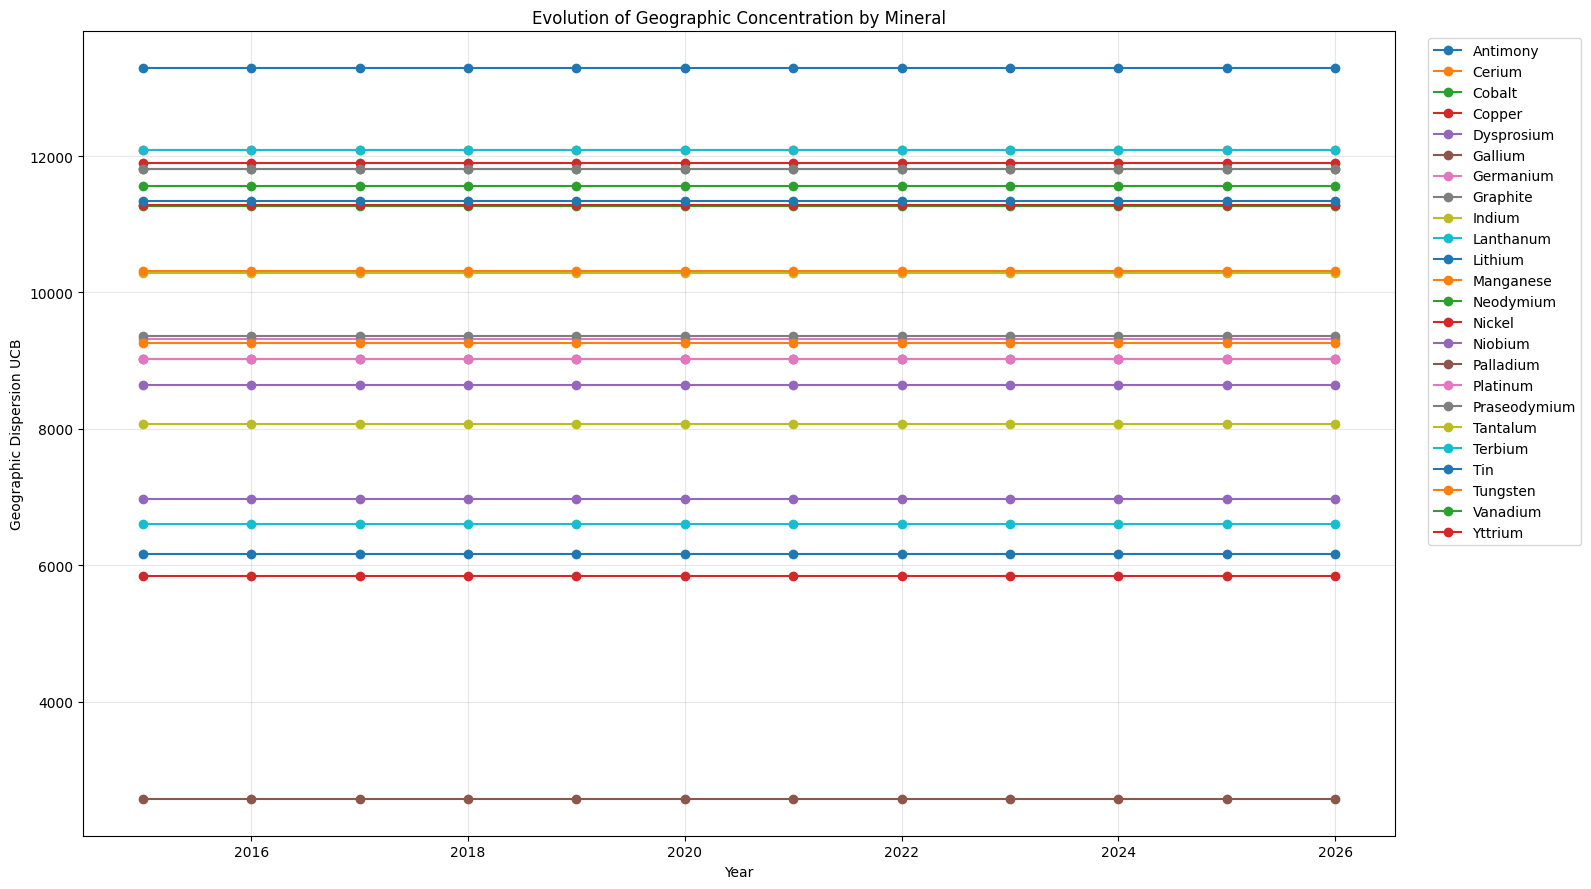

In [60]:
import matplotlib.pyplot as plt

ranking_temporal = (
    master
    .dropna(subset=['Latitude (average)', 'Longitude (average)'])
    .groupby(['mineral', 'year'], group_keys=False)
    .apply(ucb_dispersion)
    .reset_index()
    .sort_values(['mineral', 'year'])
    .reset_index(drop=True)
)

print(ranking_temporal.to_string(index=False))

plt.figure(figsize=(16, 9))

for mineral in ranking_temporal['mineral'].unique():
    datos_mineral = ranking_temporal[ranking_temporal['mineral'] == mineral]

    plt.plot(
        datos_mineral['year'],
        datos_mineral['Score_UCB'],
        marker='o',
        linewidth=1.5,
        label=mineral
    )

plt.xlabel('Year')
plt.ylabel('Geographic Dispersion UCB')
plt.title('Evolution of Geographic Concentration by Mineral')

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()